# Linear Regression Baseline for CMAPSS FD001

This notebook trains a linear regression baseline and a PCA-enhanced linear regression model to predict remaining useful life (RUL) for the CMAPSS jet engine dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [2]:
DATASET = "FD001"
RANDOM_STATE = 42
MAX_RUL = 125  # Set to None if you do not want to cap the target.

index_cols = ["engine_id", "cycle"]
setting_cols = [f"setting_{i}" for i in range(1, 4)]
sensor_cols = [f"sensor_{i}" for i in range(1, 22)]
columns = index_cols + setting_cols + sensor_cols

train_path = f"CMAPSSData/train_{DATASET}.txt"
test_path = f"CMAPSSData/test_{DATASET}.txt"
rul_path = f"CMAPSSData/RUL_{DATASET}.txt"

train_df = pd.read_csv(train_path, sep=r"\s+", header=None)
test_df = pd.read_csv(test_path, sep=r"\s+", header=None)
test_rul = pd.read_csv(rul_path, sep=r"\s+", header=None)

train_df.columns = columns
test_df.columns = columns
test_rul.columns = ["true_rul"]
test_rul["engine_id"] = np.arange(1, len(test_rul) + 1)

train_df = train_df.sort_values(["engine_id", "cycle"]).reset_index(drop=True)
test_df = test_df.sort_values(["engine_id", "cycle"]).reset_index(drop=True)

max_cycle_by_engine = train_df.groupby("engine_id")["cycle"].transform("max")
train_df["RUL"] = max_cycle_by_engine - train_df["cycle"]

if MAX_RUL is not None:
    train_df["RUL"] = train_df["RUL"].clip(upper=MAX_RUL)

candidate_features = [c for c in train_df.columns if c not in ["engine_id", "RUL"]]

print(f"Training rows: {len(train_df):,}")
print(f"Test rows: {len(test_df):,}")
print(f"Number of engines in training set: {train_df['engine_id'].nunique()}")
print(f"Number of engines in test set: {test_df['engine_id'].nunique()}")
print(f"Candidate features before filtering ({len(candidate_features)}): {candidate_features}")

Training rows: 20,631
Test rows: 13,096
Number of engines in training set: 100
Number of engines in test set: 100
Candidate features before filtering (25): ['cycle', 'setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [3]:
train_df.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,125
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,125
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,125


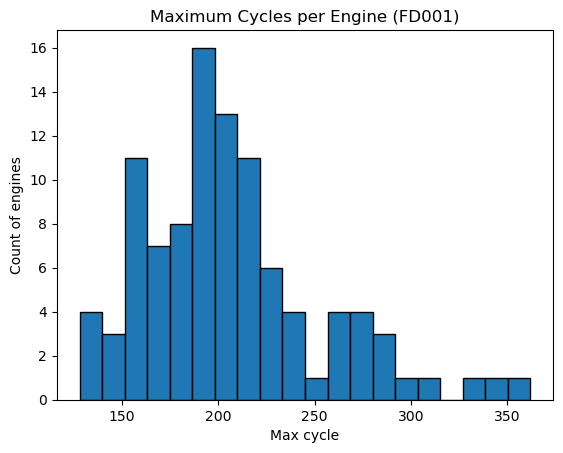

In [4]:
cycles = train_df.groupby("engine_id")["cycle"].max()
cycles.plot(kind="hist", bins=20, edgecolor="black")
plt.title(f"Maximum Cycles per Engine ({DATASET})")
plt.xlabel("Max cycle")
plt.ylabel("Count of engines")
plt.show()

## Train and Validate Baseline Model

In [5]:
engine_ids = train_df["engine_id"].unique()
train_engine_ids, val_engine_ids = train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=RANDOM_STATE
)

train_split = train_df[train_df["engine_id"].isin(train_engine_ids)].copy()
val_split = train_df[train_df["engine_id"].isin(val_engine_ids)].copy()

constant_features = [c for c in candidate_features if train_split[c].nunique() <= 1]
feature_cols = [c for c in candidate_features if c not in constant_features]

print(f"Training engines: {len(train_engine_ids)}")
print(f"Validation engines: {len(val_engine_ids)}")
print(f"Dropped constant features: {constant_features}")
print(f"Features used ({len(feature_cols)}): {feature_cols}")

X_train = train_split[feature_cols]
y_train = train_split["RUL"]
X_val = val_split[feature_cols]
y_val = val_split["RUL"]

lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("linear_regression", LinearRegression())
])

lr_model.fit(X_train, y_train)
val_pred = lr_model.predict(X_val)

Training engines: 80
Validation engines: 20
Dropped constant features: ['setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Features used (18): ['cycle', 'setting_1', 'setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [6]:
val_rmse = float(np.sqrt(mean_squared_error(y_val, val_pred)))
val_mae = float(mean_absolute_error(y_val, val_pred))
val_r2 = float(r2_score(y_val, val_pred))

validation_metrics = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R^2"],
    "Linear Regression": [val_rmse, val_mae, val_r2]
})

display(validation_metrics)

print(f"Validation RMSE: {val_rmse:.3f}")
print(f"Validation MAE: {val_mae:.3f}")
print(f"Validation R^2: {val_r2:.3f}")

,Metric,Linear Regression
0,RMSE,17.902016
1,MAE,14.476833
2,R^2,0.815836


Validation RMSE: 17.902
Validation MAE: 14.477
Validation R^2: 0.816


## Evaluate Baseline on Official Test Set

In [7]:
test_last = test_df.groupby("engine_id").tail(1).copy()
test_last = test_last.merge(test_rul, on="engine_id", how="left")

if MAX_RUL is not None:
    test_last["true_rul"] = test_last["true_rul"].clip(upper=MAX_RUL)

test_pred = lr_model.predict(test_last[feature_cols])
test_rmse = float(np.sqrt(mean_squared_error(test_last["true_rul"], test_pred)))
test_mae = float(mean_absolute_error(test_last["true_rul"], test_pred))
test_r2 = float(r2_score(test_last["true_rul"], test_pred))

test_metrics = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R^2"],
    "Linear Regression": [test_rmse, test_mae, test_r2]
})

display(test_metrics)

print(f"Test RMSE: {test_rmse:.3f}")
print(f"Test MAE: {test_mae:.3f}")
print(f"Test R^2: {test_r2:.3f}")

results_df = pd.DataFrame({
    "engine_id": test_last["engine_id"],
    "actual_rul": test_last["true_rul"],
    "predicted_rul": np.round(test_pred, 2),
    "error": np.round(test_pred - test_last["true_rul"], 2)
}).sort_values("engine_id")

results_df.head(10)

,Metric,Linear Regression
0,RMSE,21.377232
1,MAE,16.709188
2,R^2,0.715427


Test RMSE: 21.377
Test MAE: 16.709
Test R^2: 0.715


,engine_id,actual_rul,predicted_rul,error
0,1,112,125.68,13.68
1,2,98,104.54,6.54
2,3,69,73.65,4.65
3,4,82,81.87,-0.13
4,5,91,91.44,0.44
5,6,93,92.28,-0.72
6,7,91,91.91,0.91
7,8,95,72.27,-22.73
8,9,111,97.49,-13.51
9,10,96,79.24,-16.76


## Overprediction vs Underprediction

In [8]:
mean_signed_error = float(results_df["error"].mean())
median_signed_error = float(results_df["error"].median())
over_predictions = int((results_df["error"] > 0).sum())
under_predictions = int((results_df["error"] < 0).sum())
exact_predictions = int((results_df["error"] == 0).sum())

bias_summary = pd.DataFrame({
    "Metric": [
        "Mean signed error",
        "Median signed error",
        "Over-predictions",
        "Under-predictions",
        "Exact predictions"
    ],
    "Value": [
        mean_signed_error,
        median_signed_error,
        over_predictions,
        under_predictions,
        exact_predictions
    ]
})

display(bias_summary)

if mean_signed_error > 0:
    print(f"On average, the model over-predicts by {mean_signed_error:.2f} cycles.")
elif mean_signed_error < 0:
    print(f"On average, the model under-predicts by {abs(mean_signed_error):.2f} cycles.")
else:
    print("On average, the model is unbiased in signed error.")

,Metric,Value
0,Mean signed error,3.0827
1,Median signed error,2.8350
2,Over-predictions,56.0000
3,Under-predictions,44.0000
4,Exact predictions,0.0000


On average, the model over-predicts by 3.08 cycles.


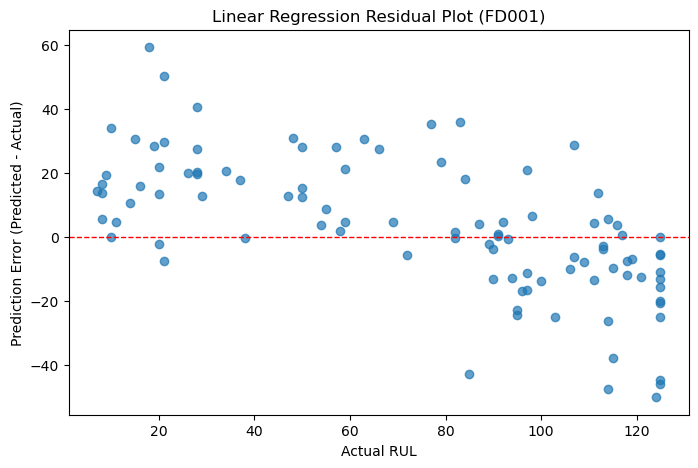

In [9]:
plt.figure(figsize=(8, 5))
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.scatter(results_df["actual_rul"], results_df["error"], alpha=0.7)
plt.xlabel("Actual RUL")
plt.ylabel("Prediction Error (Predicted - Actual)")
plt.title(f"Linear Regression Residual Plot ({DATASET})")
plt.show()

## PCA Comparison

In [10]:
pca_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("linear_regression", LinearRegression())
])

pca_model.fit(X_train, y_train)
pca_val_pred = pca_model.predict(X_val)
pca_test_pred = pca_model.predict(test_last[feature_cols])

pca_val_rmse = float(np.sqrt(mean_squared_error(y_val, pca_val_pred)))
pca_val_mae = float(mean_absolute_error(y_val, pca_val_pred))
pca_val_r2 = float(r2_score(y_val, pca_val_pred))

pca_test_rmse = float(np.sqrt(mean_squared_error(test_last["true_rul"], pca_test_pred)))
pca_test_mae = float(mean_absolute_error(test_last["true_rul"], pca_test_pred))
pca_test_r2 = float(r2_score(test_last["true_rul"], pca_test_pred))

comparison_df = pd.DataFrame({
    "Metric": ["Validation RMSE", "Validation MAE", "Validation R^2", "Test RMSE", "Test MAE", "Test R^2"],
    "Linear Regression": [val_rmse, val_mae, val_r2, test_rmse, test_mae, test_r2],
    "Linear Regression + PCA": [pca_val_rmse, pca_val_mae, pca_val_r2, pca_test_rmse, pca_test_mae, pca_test_r2]
})

display(comparison_df)

print(f"PCA components kept: {pca_model.named_steps['pca'].n_components_}")
print(f"Explained variance retained: {pca_model.named_steps['pca'].explained_variance_ratio_.sum():.4f}")

,Metric,Linear Regression,Linear Regression + PCA
0,Validation RMSE,17.902016,17.911170
1,Validation MAE,14.476833,14.475526
2,Validation R^2,0.815836,0.815647
3,Test RMSE,21.377232,21.452159
4,Test MAE,16.709188,16.785472
5,Test R^2,0.715427,0.713429


PCA components kept: 13
Explained variance retained: 0.9598


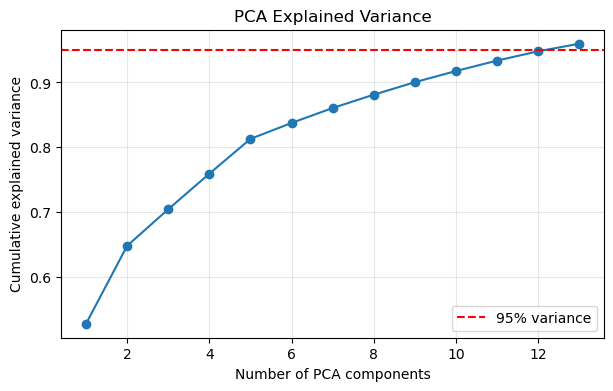

In [11]:
explained_variance = np.cumsum(pca_model.named_steps["pca"].explained_variance_ratio_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker="o")
plt.axhline(0.95, color="red", linestyle="--", label="95% variance")
plt.xlabel("Number of PCA components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Explained Variance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Visualizations

cycle        10.662179
sensor_11     4.677663
sensor_9      4.283138
sensor_14     3.568938
sensor_12     3.500130
sensor_7      3.158194
sensor_4      3.045679
sensor_15     2.695995
sensor_2      2.046080
sensor_20     1.910108
dtype: float64

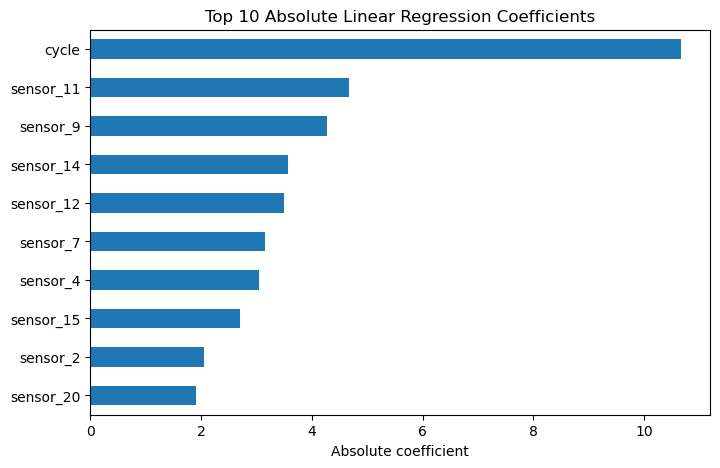

In [12]:
linear_coefficients = pd.Series(
    np.abs(lr_model.named_steps["linear_regression"].coef_),
    index=feature_cols
).sort_values(ascending=False)

display(linear_coefficients.head(10))

linear_coefficients.head(10).sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Top 10 Absolute Linear Regression Coefficients")
plt.xlabel("Absolute coefficient")
plt.show()

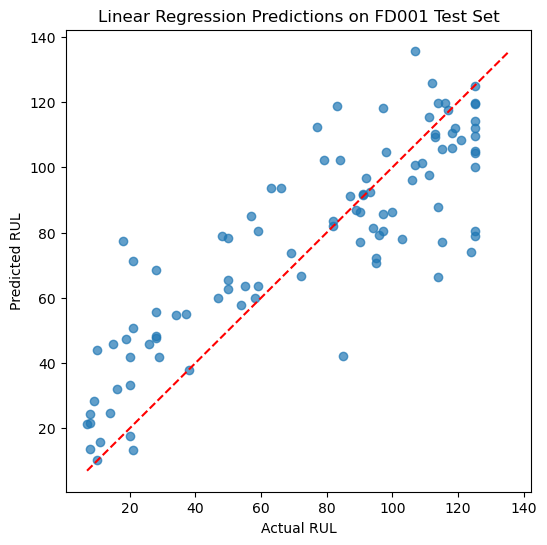

In [13]:
plt.figure(figsize=(6, 6))
plt.scatter(test_last["true_rul"], test_pred, alpha=0.7)
min_val = min(test_last["true_rul"].min(), test_pred.min())
max_val = max(test_last["true_rul"].max(), test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--")
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title(f"Linear Regression Predictions on {DATASET} Test Set")
plt.show()

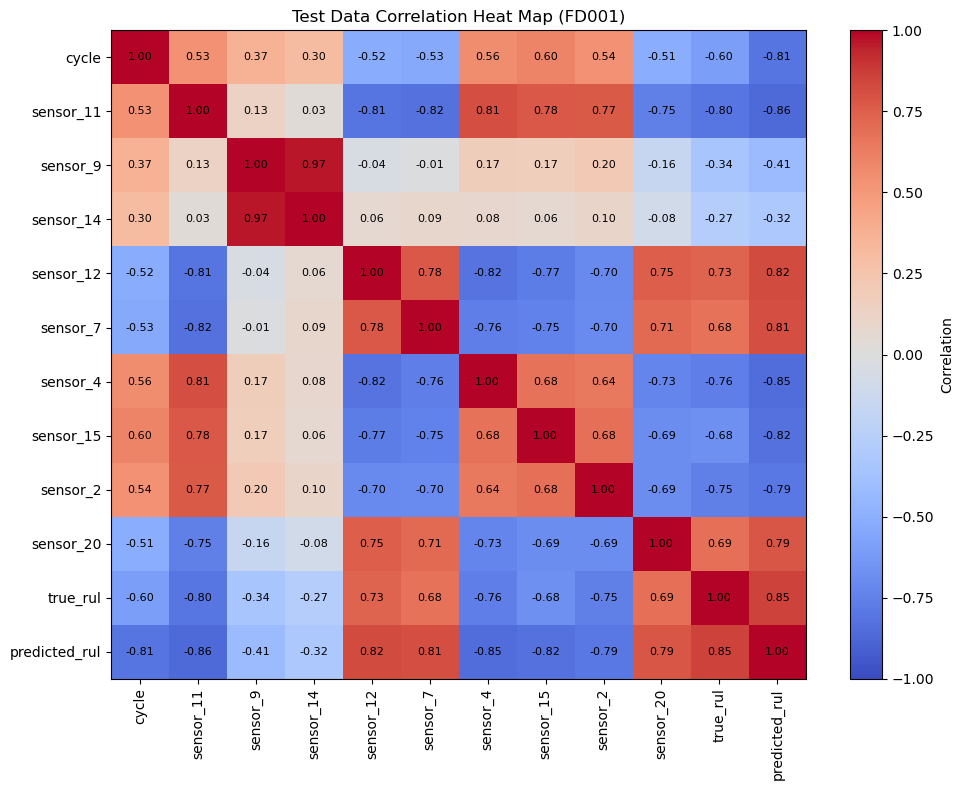

In [14]:
top_heatmap_features = linear_coefficients.head(10).index.tolist()
heatmap_df = test_last[top_heatmap_features].copy()
heatmap_df["true_rul"] = test_last["true_rul"].values
heatmap_df["predicted_rul"] = test_pred

corr_matrix = heatmap_df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title(f"Test Data Correlation Heat Map ({DATASET})")

for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8, color="black")

plt.tight_layout()
plt.show()

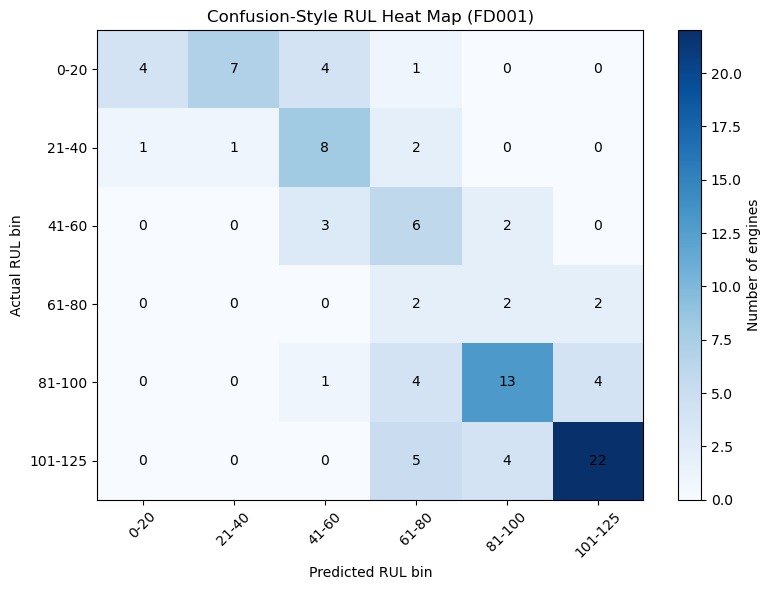

predicted_bin,0-20,21-40,41-60,61-80,81-100,101-125
actual_bin,,,,,,
0-20,4,7,4,1,0,0
21-40,1,1,8,2,0,0
41-60,0,0,3,6,2,0
61-80,0,0,0,2,2,2
81-100,0,0,1,4,13,4
101-125,0,0,0,5,4,22


In [15]:
bin_edges = [0, 20, 40, 60, 80, 100, 125]
bin_labels = ["0-20", "21-40", "41-60", "61-80", "81-100", "101-125"]

confusion_df = results_df.copy()
confusion_df["actual_bin"] = pd.cut(
    confusion_df["actual_rul"],
    bins=bin_edges,
    labels=bin_labels,
    include_lowest=True
)
confusion_df["predicted_bin"] = pd.cut(
    confusion_df["predicted_rul"],
    bins=bin_edges,
    labels=bin_labels,
    include_lowest=True
)

confusion_matrix = pd.crosstab(
    confusion_df["actual_bin"],
    confusion_df["predicted_bin"],
    dropna=False
)

plt.figure(figsize=(8, 6))
plt.imshow(confusion_matrix, cmap="Blues", aspect="auto")
plt.colorbar(label="Number of engines")
plt.xticks(range(len(confusion_matrix.columns)), confusion_matrix.columns, rotation=45)
plt.yticks(range(len(confusion_matrix.index)), confusion_matrix.index)
plt.xlabel("Predicted RUL bin")
plt.ylabel("Actual RUL bin")
plt.title(f"Confusion-Style RUL Heat Map ({DATASET})")

for i in range(confusion_matrix.shape[0]):
    for j in range(confusion_matrix.shape[1]):
        plt.text(j, i, confusion_matrix.iloc[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

confusion_matrix